In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [175]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [176]:
dataset = load_iris()
print("iris data loaded")

# print(f"dataset.data {dataset.data}")
# print(f"dataset.target{dataset.target}")
# print(f"target names: {dataset.target_names}")
Y = dataset.target
X = dataset.data

iris data loaded


In [177]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8)
print(X_train.shape)
print(Y_train.shape)

(120, 4)
(120,)


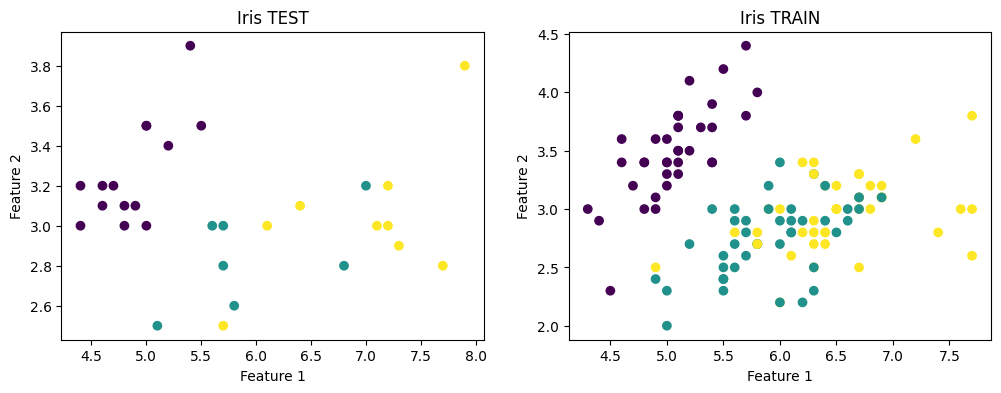

In [178]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris TEST")
plt.subplot(122)
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap="viridis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris TRAIN")
plt.show()

score de base = 0.9666666666666667


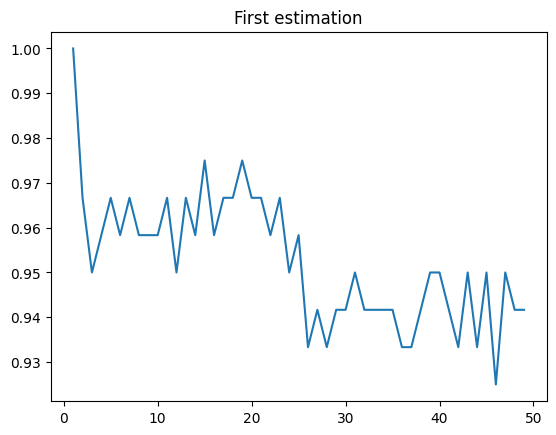

In [179]:
model = KNeighborsClassifier()
model.fit(X_train, Y_train)
scoredebase = model.score(X_train, Y_train)
print(f"score de base = {scoredebase}")
scores = []
for i in range(1, 50):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, Y_train)
    scoredebase = model.score(X_train, Y_train)
    scores.append(scoredebase)
scores
time = [i for i in range(1, 50)]
plt.plot(time, scores)
plt.title("First estimation")
plt.show()

from sklearn

In [180]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import validation_curve

on se cree un validation set danns le train set, apres, GridSearchCV fera le sien, donc pas de besoins ici, c est juste pour l exemple. On ne s en servira plus apres...

In [181]:
crossvalscore = cross_val_score(KNeighborsClassifier(), X_train, Y_train, cv=5, scoring='accuracy')
crossvalscore.mean()


0.9333333333333333

In [182]:
KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [183]:
train_score, val_curve = validation_curve(KNeighborsClassifier(), X_train, Y_train,param_range=time, param_name='n_neighbors', cv=5)
val_curve

array([[0.91666667, 0.95833333, 0.91666667, 0.95833333, 0.91666667],
       [0.91666667, 0.95833333, 0.91666667, 0.95833333, 0.91666667],
       [0.95833333, 0.95833333, 0.91666667, 0.95833333, 0.91666667],
       [0.875     , 0.95833333, 0.875     , 0.95833333, 0.91666667],
       [0.91666667, 0.95833333, 0.91666667, 0.95833333, 0.91666667],
       [0.91666667, 1.        , 0.91666667, 0.95833333, 0.91666667],
       [0.91666667, 0.95833333, 0.91666667, 0.95833333, 0.91666667],
       [0.91666667, 1.        , 0.875     , 0.95833333, 0.91666667],
       [0.91666667, 0.95833333, 0.875     , 0.95833333, 0.91666667],
       [0.91666667, 0.95833333, 0.875     , 0.91666667, 0.95833333],
       [0.91666667, 0.95833333, 0.91666667, 0.95833333, 0.91666667],
       [0.91666667, 0.95833333, 0.91666667, 0.95833333, 0.95833333],
       [0.91666667, 0.95833333, 1.        , 0.95833333, 0.95833333],
       [0.91666667, 1.        , 0.91666667, 0.95833333, 0.91666667],
       [0.91666667, 1.        , 0.

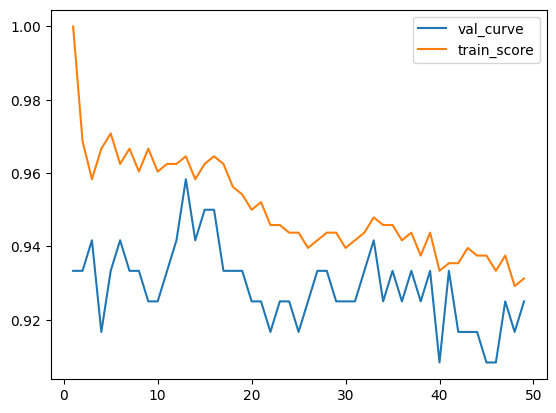

In [184]:
plt.plot(time, val_curve.mean(axis=1), label="val_curve")
plt.plot(time, train_score.mean(axis=1), label="train_score")
plt.legend()
plt.show()

on voit direct que le max est atteint a entre [10 : 20]

In [185]:
from sklearn.model_selection import GridSearchCV

In [186]:
KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [187]:
param_grid = {
    'n_neighbors': np.arange(1, 20),
    'metric': ['minkowski', 'eucludian', 'manhattan'],
    'weights':['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

In [188]:
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, Y_train)

/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
760 fits failed out of a total of 2280.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
760 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/Users/fabiochaput/Documents/VS/portfolio/Car

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'metric': ['minkowski', 'eucludian', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                         'weights': ['uniform', 'distance']})

In [189]:
grid.best_params_

{'algorithm': 'auto',
 'metric': 'minkowski',
 'n_neighbors': 13,
 'weights': 'uniform'}

In [190]:
model = grid.best_estimator_

In [191]:
model.score(X_test, Y_test)

1.0

In [192]:
from sklearn.model_selection import learning_curve

In [193]:
chunks, train_score, val_score = learning_curve(model, X_train, Y_train, train_sizes=np.linspace(0.1, 1.0, 15))

/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 472, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/fabiochaput/Documents/VS/portfolio/CardFraud/venv/lib/python3.11/site-packages/sklearn/neighbors/_classification.py", line 446, in score
    return super().score(X, y, sample_weight)
    

In [194]:
chunks

array([ 9, 15, 21, 28, 34, 40, 46, 52, 58, 65, 71, 77, 83, 89, 96])

In [195]:
train_score

array([[       nan,        nan,        nan,        nan,        nan],
       [0.46666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667],
       [0.47619048, 0.76190476, 0.80952381, 0.80952381, 0.80952381],
       [0.92857143, 0.82142857, 0.85714286, 0.85714286, 0.85714286],
       [0.97058824, 0.94117647, 0.88235294, 0.88235294, 0.88235294],
       [0.95      , 0.975     , 0.9       , 0.9       , 0.9       ],
       [0.97826087, 0.97826087, 0.93478261, 0.91304348, 0.91304348],
       [0.98076923, 0.96153846, 0.96153846, 0.96153846, 0.96153846],
       [0.94827586, 0.96551724, 0.94827586, 0.96551724, 0.96551724],
       [0.93846154, 0.95384615, 0.95384615, 0.95384615, 0.95384615],
       [0.97183099, 0.95774648, 0.95774648, 0.97183099, 0.97183099],
       [0.96103896, 0.97402597, 0.94805195, 0.97402597, 0.97402597],
       [0.96385542, 0.97590361, 0.95180723, 0.97590361, 0.96385542],
       [0.95505618, 0.97752809, 0.97752809, 0.97752809, 0.96629213],
       [0.95833333, 0.96875   , 0.

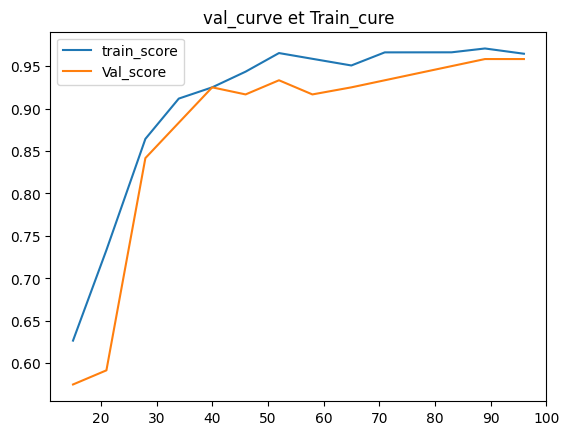

In [196]:
plt.plot(chunks, train_score.mean(axis=1), label="train_score")
plt.plot(chunks, val_score.mean(axis=1), label="Val_score")
plt.legend()
plt.title("val_curve et Train_cure")
plt.show()

le model atteint un plafond d'apprentissage vers 60/70 .... il ne sert donc plus a rien de collecter de la donnee  passe ce seuil des 70.

In [197]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.metrics import confusion_matrix

In [198]:
y_pred = model.predict(X_test)
y_pred
model.score(X_train, Y_train)




0.9666666666666667

<Axes: >

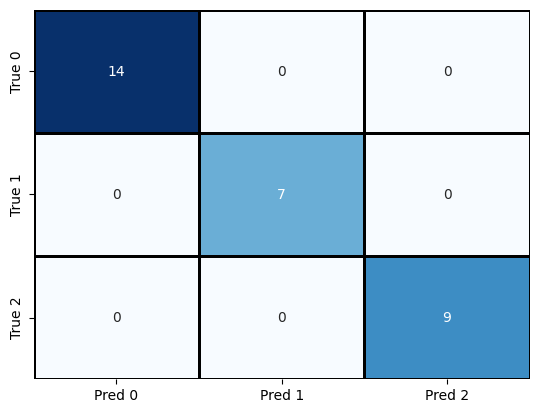

In [199]:

sns.heatmap(confusion_matrix(Y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1", "Pred 2"],
    yticklabels=["True 0", "True 1", "True 2"],
    linewidths=1,
    linecolor="black")

On teste les trois types d erreur, qui ont des methodes de claculs differentes, plsu ou moins sensibles aux outliers


In [200]:
print(mean_squared_error(Y_test, y_pred))
print(mean_absolute_error(Y_test, y_pred))
print(median_absolute_error(Y_test, y_pred))


0.0
0.0
0.0
